In [1]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [31]:
dataset = "archive\leapGestRecog"

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset,
    target_size=(64,64),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_data = datagen.flow_from_directory(
    dataset,
    target_size=(64,64),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5387 images belonging to 5 classes.
Found 1349 images belonging to 5 classes.


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = train_data.num_classes

model = Sequential([
    Input(shape=(64,64,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,269 (2.61 MB)

 Trainable params: 683,269 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
print(train_data.class_indices)
print("Number of classes:", len(train_data.class_indices))

{'.ipynb_checkpoints': 0, '00': 1, '01': 2, '02': 3, '03': 4}
Number of classes: 5


In [17]:
Dense(10, activation='softmax')

<Dense name=dense_6, built=False>

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8851 - loss: 0.2901 - val_accuracy: 0.7368 - val_loss: 0.8439
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 67s 398ms/step - accuracy: 0.9972 - loss: 0.0124 - val_accuracy: 0.7168 - val_loss: 1.4076
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 57s 335ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.7220 - val_loss: 1.2766
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 62s 370ms/step - accuracy: 1.0000 - loss: 8.4845e-04 - val_accuracy: 0.8421 - val_loss: 1.0301
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 70s 415ms/step - accuracy: 1.0000 - loss: 2.3531e-04 - val_accuracy: 0.8302 - val_loss: 1.0228
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 67s 323ms/step - accuracy: 0.9998 - loss: 8.6809e-04 - val_accuracy: 0.8080 - val_loss: 1.2542
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 50s 293ms/step - accuracy: 0.9968 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 8/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 53s 316ms/step - accuracy: 0.9993

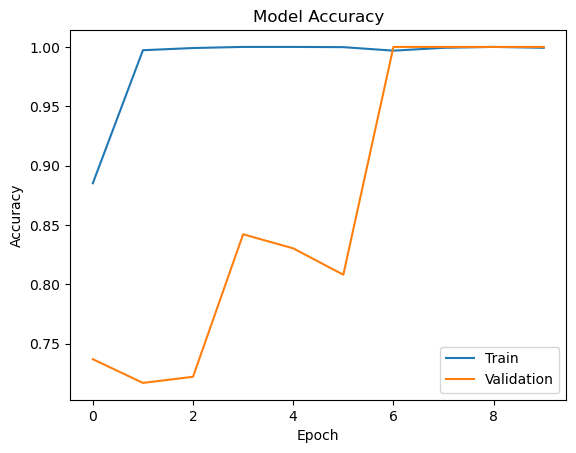

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [28]:
model.save('gesture_model.keras')

In [33]:
import os

dataset = r"archive\leapGestRecog"

print(os.path.exists(dataset))
print(os.listdir(dataset))

True
['.ipynb_checkpoints', '00', '01', '02', '03', '04', '05', '06', '07', '08', '09', 'leapGestRecog']


In [34]:
import os

dataset = r"archive\leapGestRecog"

for root, dirs, files in os.walk(dataset):
    for file in files:
        if file.endswith(".png"):
            print(os.path.join(root, file))
            raise SystemExit

archive\leapGestRecog\00\01_palm\frame_00_01_0001.png


SystemExit: 

D:\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [36]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    r"archive\leapGestRecog\00\01_palm\frame_00_01_0001.png",
    color_mode='grayscale',
    target_size=(64,64)
)

img = image.img_to_array(img)

img = img/255.0

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1
